# Skyrmion in a disk

## Import libraries

In [1]:
import pyvista as pv
from scipy import constants

import neuralmag as nm

pv.set_jupyter_backend("static")

2025-04-16 15:04:49 NeuralMag:INFO [NeuralMag] Version 0.9.1


## Create mesh and state
We create a 2D nodal mesh (mesh with just 1 layer of nodes in the z-direction) with $50 \times 50$ cells with cell size $2 \times 2 \times 0.6\,\text{nm}^3$.

In [2]:
mesh = nm.Mesh((50, 50), (2e-9, 2e-9, 0.6e-9), (-50e-9, -50e-9, 0))
state = nm.State(mesh)

2025-04-16 15:04:49 NeuralMag:INFO [Mesh] 2D, 50 x 50 (size = 2e-09 x 2e-09 x 6e-10)
2025-04-16 15:04:50 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2025-04-16 15:04:50 NeuralMag:INFO [NeuralMag] Set default device to 'TFRT_CPU_0'.
2025-04-16 15:04:50 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-04-16 15:04:50 NeuralMag:INFO [State] Running on device: TFRT_CPU_0 (dtype = float32, backend = jax)


## Set material parameters

In [3]:
state.material.Ms = 1.0 / constants.mu_0
state.material.A = 1.6e-11
state.material.Di = 4e-3
state.material.Di_axis = [0, 0, 1]
state.material.Ku = 510e3
state.material.Ku_axis = [0, 0, 1]
state.material.alpha = 0.1

## Define circular geometry
Set cell function `state.rho` to 1. within disk region and to `state.eps` in the air region. 

In [4]:
x, y = state.coordinates()
state.rho = nm.CellFunction(
    state,
    tensor=nm.config.backend.np.where(
        x**2.0 + y**2.0 < 50e-9**2.0, 1.0, state.eps
    ),
)

## Set initial magnetization

In [5]:
state.m = nm.VectorFunction(state).fill((0, 0, 1))

## Register effective field
The effective field comprises exchange, demag, interface DMI and uniaxial anisotropy contributions

In [6]:
nm.ExchangeField().register(state, "exchange")
nm.DemagField().register(state, "demag")
nm.InterfaceDMIField().register(state, "dmi")
nm.UniaxialAnisotropyField().register(state, "aniso")
nm.TotalField("exchange", "demag", "dmi", "aniso").register(state)

2025-04-16 15:04:51 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-04-16 15:04:51 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-04-16 15:04:51 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-04-16 15:04:53 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_dmi', energy: 'E_dmi')
2025-04-16 15:04:53 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_aniso', energy: 'E_aniso')
2025-04-16 15:04:53 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


## Relax to skyrmion configuration

In [7]:
llg = nm.LLGSolver(state)
llg.relax(1e9)
state.write_vti(["m", "rho"], "skyrmion.vti")

2025-04-16 15:04:53 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2025-04-16 15:04:54 NeuralMag:INFO [LLGSolverJAX] Relaxation started, initial energy E = -5.76998e-19 J
2025-04-16 15:04:56 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 8.85105e+11) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 6.79926e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 5.37774e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 5.64878e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 4.86677e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 3.03364e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.90586e+10) 1/s
2025-04-16 15:04:59 NeuralMag:INFO [LLGSolverJAX] Relaxation step (max dm/dt = 1.86547e+10) 1/s
2025-04-16 15:05:00 NeuralMag:INFO [LLGSolverJAX] Rela

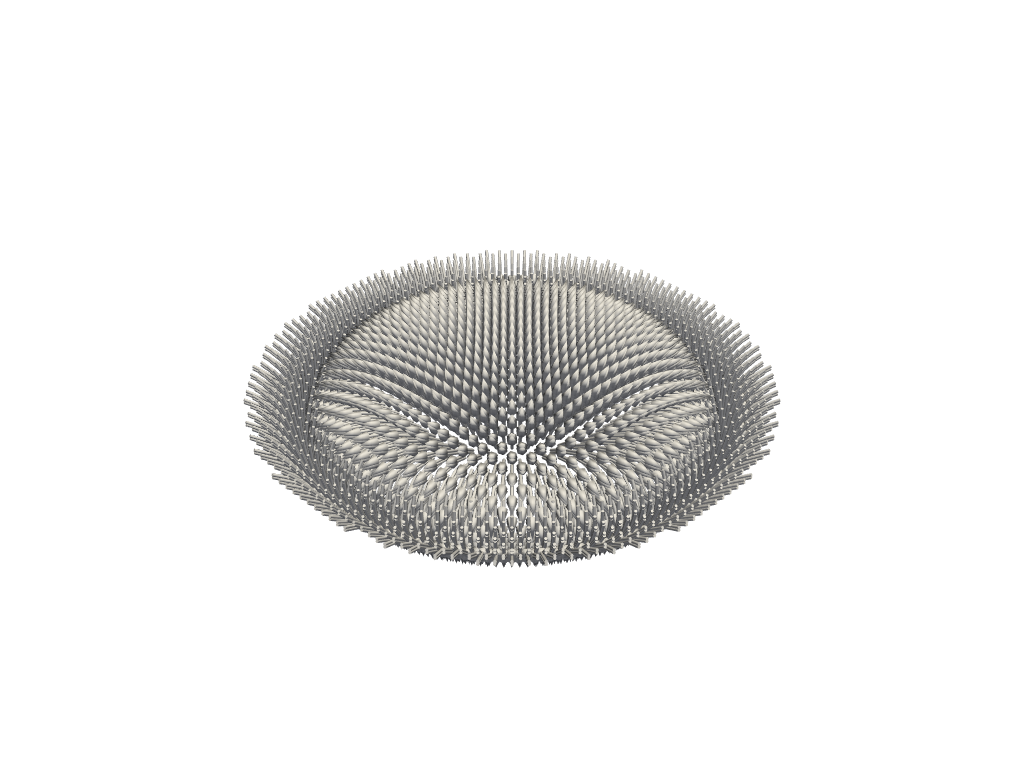

In [9]:
grid = pv.read("skyrmion.vti")

thresholded = grid.threshold(value=0.5, scalars="rho", preference="cell")
glyphs = thresholded.glyph(orient="m", scale="m", factor=1e-8)

# Plot
plotter = pv.Plotter()
plotter.add_mesh(glyphs, color="white", lighting=True, smooth_shading=True)
plotter.show()